# Getting started: fill one flux series

One complete gap-filling run, on a synthetic eddy-covariance site, so there is
nothing to download. By the end you will have:

1. looked at the data the package expects;
2. built a configuration;
3. fitted RFR3 on latent heat (`LE`) and filled its gaps;
4. checked the filled values against the noise-free truth that only a
   synthetic site can give you;
5. recorded the run in a JSON manifest.

The method is explained in [`docs/method.md`](../../docs/method.md). The
notebook runs in under a minute.

In [1]:
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import rfrgapfill
from rfrgapfill import (
    FeatureConfig,
    RFRGapFiller,
    RunManifest,
    core_metrics,
    feature_names,
    load_manifest,
    receptive_limiter_features,
    synthetic_site,
)

# Show warnings as one line, without the path of the file that raised them.
warnings.formatwarning = lambda message, category, *args, **kwargs: (
    f"{category.__name__}: {message}\n"
)

# Series colours, always used in this order, and grey for the chart furniture.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MUTED = "#898781"
plt.rcParams.update(
    {
        "figure.figsize": (10, 3.6),
        "axes.prop_cycle": plt.cycler(color=SERIES),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": "#52514e",
        "axes.titlelocation": "left",
        "axes.grid": True,
        "grid.color": "#e1e0d9",
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "lines.linewidth": 1.5,
        "legend.frameon": False,
    }
)
print("rfrgapfill", rfrgapfill.__version__)

rfrgapfill 0.1.0


## 1. A site to work on

`synthetic_site()` generates one seeded year of half-hourly data at 45° N:
ten meteorological drivers under their FLUXNET2015 names, and three fluxes
(`NEE`, `H`, `LE`) with a QC flag each. The fluxes are functions of the
drivers plus measurement noise, and they carry the two kinds of hole real
towers have: outages where nothing was recorded, and values that arrive
already gap-filled by someone else.

In [2]:
site = synthetic_site()
print(f"{site.site_id}: {len(site.frame)} rows at {site.time_step}, latitude {site.latitude}")
print("drivers:", ", ".join(site.column_map.variables.values()))
print("targets:", ", ".join(site.targets))
site.frame.head()

SYN-Ref: 17520 rows at 0:30:00, latitude 45.0
drivers: SW_IN_F, VPD_F_MDS, TA_F_MDS, NETRAD, WS, WD, G_F_MDS, TS_F_MDS, RH, SWC_F_MDS
targets: NEE, H, LE


,SW_IN_F,VPD_F_MDS,TA_F_MDS,NETRAD,WS,WD,G_F_MDS,TS_F_MDS,RH,SWC_F_MDS,NEE,NEE_QC,H,H_QC,LE,LE_QC
2018-01-01 00:00:00,0.0,1.392582,0.845334,-75.0,3.406974,169.576999,-33.75,1.845334,78.555664,34.0,-0.512242,0,-51.634108,0,-7.296123,0
2018-01-01 00:30:00,0.0,1.701139,1.631854,-75.0,4.073614,163.870950,-33.75,1.856182,75.246886,34.0,0.051420,0,-39.464684,0,5.481970,0
2018-01-01 01:00:00,0.0,1.704540,1.692241,-75.0,4.126017,156.243745,-33.75,1.867714,75.304658,34.0,0.515288,0,-31.322728,0,-16.936593,0
2018-01-01 01:30:00,0.0,1.768017,1.744289,-75.0,4.116583,177.023398,-33.75,1.879804,74.480463,34.0,0.255282,0,-40.504945,0,25.655499,0
2018-01-01 02:00:00,0.0,1.603927,1.361850,-75.0,4.070057,190.862603,-33.75,1.886453,76.204118,34.0,-0.149312,0,-33.618715,0,2.811892,0


The QC flag decides what counts as a measurement. With the default
`observed_qc_values=(0,)`, only rows flagged `0` train the model or feed the
daily statistics. A value with any other flag is treated as *pre-filled* and
left alone; a row with no value at all is a gap to fill.

In [3]:
def row_status(target):
    present = site.frame[target].notna()
    observed = site.observed(target)
    return {
        "measured (QC 0)": int(observed.sum()),
        "pre-filled (QC not 0)": int((present & ~observed).sum()),
        "missing": int((~present).sum()),
    }


pd.DataFrame({target: row_status(target) for target in site.targets})

,NEE,H,LE
measured (QC 0),15308,15048,15130
pre-filled (QC not 0),1363,1623,1541
missing,849,849,849


A summer stretch of `LE` around its longest outage. Blue points are
measurements, orange are pre-filled values, and the blank run in the middle is
what this notebook will fill.

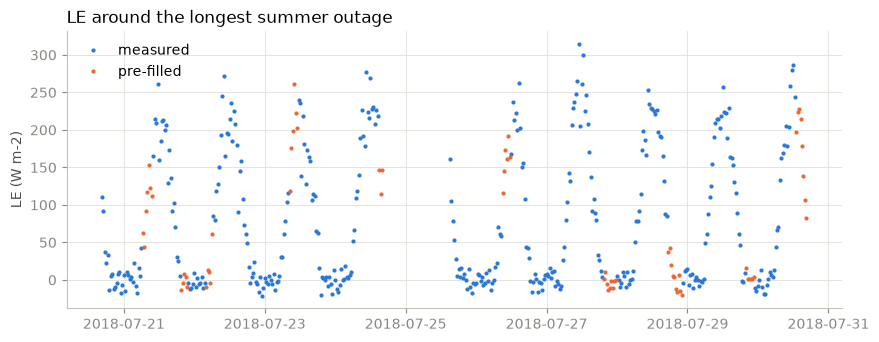

In [4]:
le = site.frame["LE"]
missing = le.isna()
run_length = missing.groupby((~missing).cumsum()).transform("sum")
summer = (le.index.month >= 5) & (le.index.month <= 9)
longest = run_length[summer & missing].idxmax()
window = slice(longest - pd.Timedelta("4D"), longest + pd.Timedelta("6D"))
observed_le = site.observed("LE")

fig, ax = plt.subplots()
shown = le[window]
ax.plot(shown.index, shown.where(observed_le[window]), ".", ms=4, label="measured")
ax.plot(shown.index, shown.where(~observed_le[window]), ".", ms=4, label="pre-filled")
ax.set_title("LE around the longest summer outage")
ax.set_ylabel("LE (W m-2)")
ax.legend(loc="upper left")
plt.show()

## 2. A configuration

`site.config()` fills in what the site already knows: cadence, latitude,
column mapping and seed. With your own data you build an `RFRConfig`
directly (see [`04_bring_your_own_data.ipynb`](04_bring_your_own_data.ipynb)).

Two settings here are deliberate:

- `daily_statistic_strategy="rolling_available"`. Under the default, a gap that
  covers whole calendar days has no daily target statistics, so none of its
  rows can be filled. This is ambiguity
  [A4](../../docs/assumptions.md#a4-days-with-too-few-measured-values).
- a one-point hyperparameter grid, for speed. Leave `hyperparameter_grid` out
  to search the package's default grid.

In [5]:
config = site.config(
    "RFR3",
    features=FeatureConfig(daily_statistic_strategy="rolling_available"),
    hyperparameter_grid={"n_estimators": (50,)},
    n_jobs=-1,
)
print("paper faithful:", config.is_paper_faithful)
print("receptive limiter adds:", receptive_limiter_features(config, target="LE"))
print("full feature order:", feature_names(config, target="LE"))

paper faithful: True
receptive limiter adds: ('radiation_category', 'time_distance_hours', 'season', 'LE_daily_q1', 'LE_daily_q2', 'LE_daily_q3', 'LE_daily_std')
full feature order: ('shortwave', 'vpd', 'air_temperature', 'radiation_category', 'time_distance_hours', 'season', 'LE_daily_q1', 'LE_daily_q2', 'LE_daily_q3', 'LE_daily_std')


`is_paper_faithful` is `True` because every setting is either the paper's or a
documented choice where the paper is silent. Turning the receptive limiter off
(the ORF benchmark) or using the historical `fluxlib` feature derivation would
make it `False`.

## 3. Fit and fill

`RFRGapFiller` trains on the measured rows of one target and predicts only
where that target has no value.

In [6]:
before = site.frame.copy(deep=True)
filler = RFRGapFiller(config).fit(site.frame, target="LE", qc_column="LE_QC")
result = filler.fill(site.frame)

print(result.report.summary())
print("best parameters:", filler.model.get_best_params())
result.frame["LE_fill_method"].value_counts()

LE: filled 849 of 849 candidate row(s) with RFR3.
best parameters: {'n_estimators': 50}


LE_fill_method
observed      15130
pre_filled     1541
RFR3            849
Name: count, dtype: int64

`result.frame` is a new frame: your input columns plus six provenance columns
for the target. Here they are across the start of the outage plotted above.

In [7]:
result.frame.loc[longest - pd.Timedelta("1h") : longest + pd.Timedelta("1h"), list(result.columns)]

,LE_original,LE_filled,LE_is_observed,LE_is_filled,LE_fill_method,LE_model_version
timestamp,,,,,,
2018-07-24 15:30:00,114.731626,114.731626,False,False,pre_filled,NaN
2018-07-24 16:00:00,145.909640,145.909640,False,False,pre_filled,NaN
2018-07-24 16:30:00,NaN,124.183986,False,True,RFR3,rfr-gapfill/0.1.0/RFR3/LE@2026-09-11T17:16:51+...
2018-07-24 17:00:00,NaN,86.765064,False,True,RFR3,rfr-gapfill/0.1.0/RFR3/LE@2026-09-11T17:16:51+...
2018-07-24 17:30:00,NaN,60.794781,False,True,RFR3,rfr-gapfill/0.1.0/RFR3/LE@2026-09-11T17:16:51+...


The rules the filler enforces can be checked directly: the input frame was
not modified, every measured value comes through unchanged, and pre-filled
values were not replaced.

In [8]:
pd.testing.assert_frame_equal(site.frame, before)
measured = result.is_observed
assert (result.filled[measured] == site.frame.loc[measured, "LE"]).all()
pre_filled = result.fill_method == "pre_filled"
assert (result.filled[pre_filled] == site.frame.loc[pre_filled, "LE"]).all()
print("input unchanged; measured and pre-filled values carried through unchanged")

input unchanged; measured and pre-filled values carried through unchanged


## 4. How good is the fill?

A real tower has no truth inside a real gap, which is why the paper validates
with *artificial* gaps (next notebook). A synthetic site does have one:
`site.truth` holds the fluxes before measurement noise was added. Scoring the
filled rows against it is a check you can only make here.

In [9]:
filled_rows = result.is_filled
scores = core_metrics(site.truth.loc[filled_rows, "LE"], result.filled[filled_rows])
print(f"{scores.n} filled rows against the noise-free truth")
print(f"R2 {scores.r2:.3f}   slope {scores.slope:.3f}")
print(f"RMSE {scores.rmse:.1f} W m-2   bias {scores.bias:+.1f} W m-2")

849 filled rows against the noise-free truth
R2 0.781   slope 0.728
RMSE 28.6 W m-2   bias -7.0 W m-2


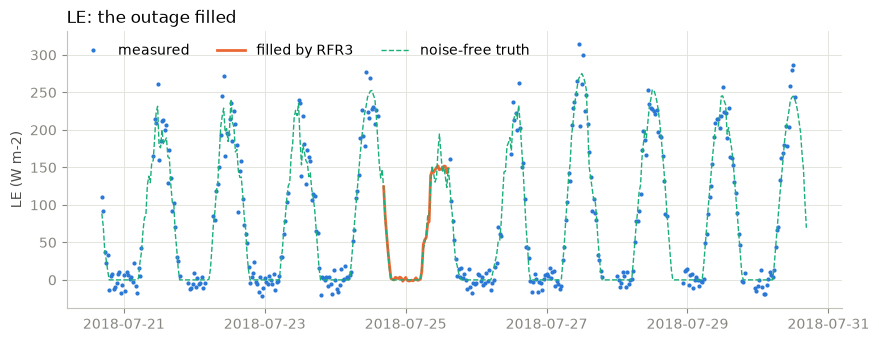

In [10]:
fig, ax = plt.subplots()
shown = result.frame.loc[window]
ax.plot(
    shown.index, shown["LE_original"].where(shown["LE_is_observed"]), ".", ms=4, label="measured"
)
ax.plot(shown.index, shown["LE_filled"].where(shown["LE_is_filled"]), lw=2, label="filled by RFR3")
ax.plot(shown.index, site.truth.loc[window, "LE"], lw=1, ls="--", label="noise-free truth")
ax.set_title("LE: the outage filled")
ax.set_ylabel("LE (W m-2)")
ax.legend(loc="upper left", ncols=3)
plt.show()

## 5. Record the run

A filled column is only as trustworthy as the record of what produced it.
`RunManifest.from_fill` collects the configuration, column mapping, QC rule,
the fitted model's parameters, the time axis, the row accounting and this
run's choice for every documented ambiguity. `save()` refuses to write a
manifest that is missing a required field.

In [11]:
manifest = RunManifest.from_fill(filler, result)
with tempfile.TemporaryDirectory() as directory:
    path = manifest.save(Path(directory) / "LE_fill.json")
    document = load_manifest(path)

print("sections:", ", ".join(document))
print("settings digest:", manifest.settings_digest[:16], "...")
document["ambiguities"]["choices"]["A4"]

sections: manifest_format, manifest_version, kind, created_at, settings_digest, reference, versions, environment_drift, run, qc, column_map, rows, time_axis, features, model, gaps, validation, fill, metrics, ambiguities, config, extra
settings digest: 8ba54674df5fea06 ...


{'topic': 'daily target statistics for a day with too few visible observations',
 'settings': {'daily_statistic_strategy': 'rolling_available',
  'min_daily_observations': 1,
  'fallback_window_days': 7}}

## Where next

- [`02_artificial_gap_validation.ipynb`](02_artificial_gap_validation.ipynb):
  measure how well RFR fills gaps of 24 hours, 7 days and 30 days, and how the
  measurement is kept free of leakage.
- [`03_comparing_configurations.ipynb`](03_comparing_configurations.ipynb):
  RFR3 against RFR10 and the ORF benchmark, and the published medians.
- [`04_bring_your_own_data.ipynb`](04_bring_your_own_data.ipynb): a
  FLUXNET2015-format file, a hand-built configuration and the command line.